In [1]:
import glob
import os
import urllib.parse
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from fink_utils.photometry.conversion import dc_mag
from myutils import all_utils as au 

# Rubin KN candidate filters

Used data transfer system
- Alerts between August 1st 2024 and 2025: **43,221,791 alerts, 2267.07GB**

## Alert class (manually introduced)
SIMBAD("galaxy"),
SIMBAD("Galaxy"),
SIMBAD("EmG"),
SIMBAD("Seyfert"),
alert_classes = [
    "(SIMBAD) Galaxy",
    "(SIMBAD) EmO",
    "(SIMBAD) Seyfert",
    "(SIMBAD) Seyfert1",
    "(SIMBAD) Seyfert2",
    "(SIMBAD) Seyfert_1",
    "(SIMBAD) Seyfert_2",
    "(SIMBAD) BlueCompG",
    "(SIMBAD) BlueCompactG",
    "(SIMBAD) StarburstG",
    "(SIMBAD) LSB_G",
    "(SIMBAD) HII_G",
    "(SIMBAD) GinCl",
    "(SIMBAD) GinGroup",
    "(SIMBAD) GinPair",
    "(SIMBAD) BCIG",
    "(SIMBAD) PartofG",
    "(SIMBAD) Compact_Gr_G",
    "(SIMBAD) IG",
    "(SIMBAD) PairG",
    "(SIMBAD) GroupG",
    "(SIMBAD) CIG",
    "(SIMBAD) SuperClG",
    "(SIMBAD) Void",
    "(SIMBAD) LINER",
    "(SIMBAD) Possible_CIG",
    "(SIMBAD) Possible_G",
    "(SIMBAD) Possible_GrG",
    "(SIMBAD) Possible_SCIG",
    "(SIMBAD) GravLens",
    "(SIMBAD) GravLensSystem",
    "Unknown",
    "(Fink) Kilonova candidates",
    "(Fink) Supernova candidates",
    "(Fink) Early Supernova Ia candidates",
    "(Fink) Microlensing candidates",
    "(Fink) Tracklet (space debris & satellite glints)",
    "(Fink) Ambiguous"
]

## Extra conditions
-- 1. Remove potential subtraction artefacts
-- 2. Far from known solar system objects
-- 3. Eliminate roids
-- 4. Recent detections (less than 20 days old)

candidate.drb > 0.9;
candidate.classtar > 0.4;
(candidate.ssdistnr > 10 OR candidate.ssdistnr < 0);
roid != 3;
(candidate.jd - candidate.jdstarthist) < 20;

**alerts after these cuts 456876 alerts**

In [2]:
# NUmber of original alerts for the year
n_alerts_year = 43221791

# Load data

In [3]:


# Load all parquet files from data/Fink/ subdirectories
parquet_files = glob.glob('data/Fink/**/*.parquet', recursive=True)
print(f"Found {len(parquet_files)} parquet files")

if len(parquet_files) == 0:
    print("No parquet files found in data/Fink/")
else:
    dfs = []
    for i, f in enumerate(parquet_files):
        try:
            df_temp = pd.read_parquet(f)
            
            # Extract finkclass from folder name
            folder_path = os.path.dirname(f)
            folder_name = os.path.basename(folder_path)
            
            if folder_name.startswith('finkclass='):
                # Extract after 'finkclass=' and decode URL encoding
                finkclass = urllib.parse.unquote(folder_name.split('finkclass=')[1])
            else:
                finkclass = folder_name
            
            # Skip if it's directly in data/Fink/ (no meaningful subfolder)
            if finkclass == 'Fink':
                continue
                
            # Add finkclass column
            df_temp['finkclass'] = finkclass
            dfs.append(df_temp)
            
            if (i + 1) % 500 == 0:
                print(f"Processed {i+1}/{len(parquet_files)} files")
                
        except Exception as e:
            print(f"Error reading {f}: {e}")
    
    if dfs:
        df = pd.concat(dfs, ignore_index=True)
        print(f"Loaded {len(df)} alerts from {len(dfs)} files")
        print(f"Shape: {df.shape}")
        print(f"Finkclass distribution:")
        print(df['finkclass'].value_counts())
        print(f"Sample of first few columns: {df.columns.tolist()[:10]}")
    else:
        print("No files could be read successfully")

Found 2869 parquet files
Processed 500/2869 files
Processed 1000/2869 files
Processed 1500/2869 files
Processed 2000/2869 files
Processed 2500/2869 files
Loaded 456876 alerts from 2869 files
Shape: (456876, 50)
Finkclass distribution:
finkclass
Unknown                   362958
SN candidate               48675
Tracklet                   42218
Early SN Ia candidate       1702
Ambiguous                    705
Kilonova candidate           251
Seyfert1                     117
GinCl                         74
Seyfert2                      49
Microlensing candidate        36
LINER                         33
ClG                           14
Seyfert_1                     13
EmG                           10
Seyfert_2                      6
LSB_G                          6
Seyfert                        4
GinGroup                       2
PairG                          1
BClG                           1
PartofG                        1
Name: count, dtype: int64
Sample of first few columns: ['magps

In [4]:
df.groupby('tnsclass').size().sort_values(ascending=False)

tnsclass
Unknown                    443328
(TNS) SN Ia                  8404
(TNS) SN II                  2341
(TNS) CV                      392
(TNS) SN Ic                   316
(TNS) SN IIn                  288
(TNS) SN Ia-91T-like          276
(TNS) SN Ic-BL                207
(TNS) SN Ib                   174
(TNS) SN IIb                  163
(TNS) SLSN-I                  125
(TNS) SN IIP                  109
(TNS) TDE                     102
(TNS) SN Iax[02cx-like]        91
(TNS) SN Ia-pec                86
(TNS) Nova                     75
(TNS) SN Ia-91bg-like          69
(TNS) SLSN-II                  63
(TNS) SN                       53
(TNS) SN Ibn                   49
(TNS) SN Ib/c                  37
(TNS) TDE-He                   35
(TNS) Galaxy                   17
(TNS) NA/Unknown               17
(TNS) SN Ia-CSM                16
(TNS) TDE-featureless          14
(TNS) SN Ia-SC                 10
(TNS) TDE-H-He                  8
(TNS) SN I                      5
(TNS)

In [5]:
df.keys().to_list()

['magpsf',
 'sigmapsf',
 'fid',
 'jd',
 'ra',
 'dec',
 'ssnamenr',
 'candid',
 'schemavsn',
 'publisher',
 'objectId',
 'brokerIngestTimestamp',
 'brokerStartProcessTimestamp',
 'fink_broker_version',
 'fink_science_version',
 'cdsxmatch',
 'DR3Name',
 'Plx',
 'e_Plx',
 'vsx',
 'spicy_id',
 'spicy_class',
 'gcvs',
 'x3hsp',
 'x4lac',
 'mangrove',
 'roid',
 'rf_snia_vs_nonia',
 'snn_snia_vs_nonia',
 'snn_sn_vs_all',
 'mulens',
 'nalerthist',
 'rf_kn_vs_nonkn',
 't2',
 'anomaly_score',
 'lc_features_g',
 'lc_features_r',
 'jd_first_real_det',
 'jdstarthist_dt',
 'mag_rate',
 'sigma_rate',
 'lower_rate',
 'upper_rate',
 'delta_time',
 'from_upper',
 'brokerEndProcessTimestamp',
 'tracklet',
 'timestamp',
 'tnsclass',
 'finkclass']

### Basic cuts

In [6]:
# BASIC CUTS - Applied in data transfer + galactic plane filter locally

# 1. Remove all alerts which are potential subtraction artefacts
# mask_high_drb = df['drb'].astype(float) > 0.9
# mask_high_classtar = df['classtar'].astype(float) > 0.4
# mask_artefacts = mask_high_drb & mask_high_classtar

# 2. Keep only extragalactic host candidates
# keep_cds = return_list_of_eg_host()
# if 'cdsxmatch' in df.columns:
#     mask_known_objects = df['cdsxmatch'].isin(keep_cds)
# else:
#     mask_known_objects = pd.Series([True] * len(df), index=df.index)
#     print("Warning: 'cdsxmatch' column not found, skipping SIMBAD filter")

# 3. Parallax Gaia
mask_plx = df['Plx']/df['e_Plx']<5 #eliminate Gaia well measured parallaxes
# 4. Variable star catalogues
mask_gcvs = df['gcvs'].isin(["Unknown","nan"])
mask_vsx = df['vsx'].isin(["Unknown","nan",'Fail 503','Fail 504','Fail 500','Fail 502'])

# 5a. Far from known solar system objects
# mask_far_from_mpc = (df['ssdistnr'].astype(float) > 10) | (df['ssdistnr'].astype(float) < 0)

# 5b. Eliminate roids (if roid column exists)
if 'roid' in df.columns:
    mask_no_roids = df['roid'] != 3
else:
    mask_no_roids = pd.Series([True] * len(df), index=df.index)
    print("Warning: 'roid' column not found, skipping roid filter")

# 6. Away from galactic plane (|b| > 10 degrees)
coords = SkyCoord(df['ra'].astype(float), df['dec'].astype(float), unit="deg")
b = coords.galactic.b.deg
mask_away_from_galactic_plane = np.abs(b) > 20

# 6. Recent detections (less than 20 days old)
# mask_new_detection = df['jd'].astype(float) - df['jdstarthist'].astype(float) < 20



mask_basic_cuts = (mask_plx & mask_gcvs & mask_vsx & mask_no_roids & mask_away_from_galactic_plane)  

# Create basic cuts dataframe
df_basic_cuts = df[mask_basic_cuts].copy()

print(f"Basic cuts summary:")
print(f"  Original alerts: {len(df)}")
# print(f"  After drb > 0.9: {mask_high_drb.sum()}")
# print(f"  After classtar > 0.4: {mask_high_classtar.sum()}")
# print(f"  After artefact removal: {mask_artefacts.sum()}")
# print(f"  After MPC distance: {(mask_artefacts & mask_far_from_mpc).sum()}")
# print(f"  After recent detection: {(mask_artefacts & mask_far_from_mpc & mask_new_detection).sum()}")
# print(f"  After roid filter: {(mask_artefacts & mask_far_from_mpc & mask_new_detection & mask_no_roids).sum()}")
# print(f"  After galactic plane: {(mask_artefacts & mask_far_from_mpc & mask_new_detection & mask_no_roids & mask_away_from_galactic_plane).sum()}")
print(f"  Final basic cuts: {len(df_basic_cuts)}")
print(f"  Basic candidates per month: {len(df_basic_cuts)/12:.0f}")
print(f"  Basic cuts vs yearly alert number: {len(df_basic_cuts)/n_alerts_year*100:.2f}%")


Basic cuts summary:
  Original alerts: 456876
  Final basic cuts: 53022
  Basic candidates per month: 4418
  Basic cuts vs yearly alert number: 0.12%


THIS IS TOO MUCH FOR LVK REPROCESSING

What are these alerts?

In [7]:
def show_finkclass_distribution(df, title="Finkclass distribution"):
    """Display count and percentage distribution of finkclass column"""
    finkclass_counts = df['finkclass'].value_counts()
    finkclass_percent = df['finkclass'].value_counts(normalize=True) * 100
    finkclass_summary = pd.DataFrame({
        'Count': finkclass_counts,
        'Percentage': finkclass_percent.round(2)
    })
    print(f"{title}:")
    print(finkclass_summary)
    return finkclass_summary

# Show distribution after basic cuts
finkclass_summary_basic = show_finkclass_distribution(df_basic_cuts, "Finkclass distribution after basic cuts")

Finkclass distribution after basic cuts:
                       Count  Percentage
finkclass                               
Unknown                50272       94.81
SN candidate            2615        4.93
Seyfert1                  65        0.12
Tracklet                  27        0.05
LINER                     13        0.02
Seyfert2                  12        0.02
Seyfert_1                  7        0.01
Early SN Ia candidate      5        0.01
Seyfert                    3        0.01
Kilonova candidate         2        0.00
EmG                        1        0.00


In [8]:
def plot_lightcurves(idxs, df):
    """Plot lightcurves for given objectIds from df"""
    for idx in idxs:
        plt.figure(figsize=(3,2))
        for i, row in df[df['objectId']==idx].iterrows():
            plt.errorbar(row['jd'], row['magpsf'],  fmt='o', label=row['fid'])
        plt.xlabel("JD")
        plt.ylabel("Magnitude")
        plt.title(f"{idx}")
        plt.legend()
    plt.show()
def plot_hist(df,xvar='magpsf',log=False):
    """Plot histograms for given DataFrame"""
    plt.figure(figsize=(5,2))
    plt.hist(df[xvar], bins=30, alpha=0.7)
    plt.xlabel(xvar)
    plt.ylabel("Count")
    if log:
        plt.yscale('log')
    plt.legend()
    plt.show()
import plotly.graph_objects as go

def plot_candidates_mollweide(df):
    """Plot candidates on Mollweide projection"""
    if len(df) == 0:
        print("No candidates to plot")
        return
    
    # Get coordinates
    ra = df['ra'].values
    dec = df['dec'].values
    
    # Wrap RA for Mollweide projection
    ra_wrapped = (ra + 180) % 360 - 180
    
    # Create color mapping based on finkclass
    finkclass_colors = {
        'Unknown': 'blue',
        'SN candidate': 'red', 
        'Seyfert1': 'green',
        'Seyfert_1': 'orange',
        'Kilonova candidate': 'purple'
    }
    
    colors = [finkclass_colors.get(fc, 'gray') for fc in df['finkclass']]
    
    fig = go.Figure()
    
    # Add scatter plot of Silver candidates
    fig.add_trace(go.Scattergeo(
        lon=ra_wrapped,
        lat=dec,
        mode='markers',
        marker=dict(
            size=8,
            color=colors,
            line=dict(width=1, color='black')
        ),
        hoverinfo='text',
        text=[f'ObjectId: {oid}<br>RA: {r:.2f}°<br>Dec: {d:.2f}°<br>Class: {fc}<br>JD: {jd:.1f}' 
              for oid, r, d, fc, jd in zip(df['objectId'], ra, dec, 
                                         df['finkclass'], df['jd'])],
        name='Silver Candidates'
    ))
    
    # Add galactic plane (±10 degrees)
    l_vals = np.linspace(0, 360, 1000)
    b_upper = 10 * np.ones_like(l_vals)
    b_lower = -10 * np.ones_like(l_vals)

    
    upper_edge = SkyCoord(l=l_vals * u.deg, b=b_upper * u.deg, frame='galactic').icrs
    lower_edge = SkyCoord(l=l_vals[::-1] * u.deg, b=b_lower[::-1] * u.deg, frame='galactic').icrs
    
    galactic_ra = np.concatenate([upper_edge.ra.deg, lower_edge.ra.deg])
    galactic_dec = np.concatenate([upper_edge.dec.deg, lower_edge.dec.deg])
    galactic_ra_wrapped = (galactic_ra + 180) % 360 - 180
    
    fig.add_trace(go.Scattergeo(
        lon=galactic_ra_wrapped,
        lat=galactic_dec,
        mode='lines',
        fill='toself',
        fillcolor='rgba(200, 100, 100, 0.3)',
        line=dict(width=0),
        hoverinfo='skip',
        showlegend=True,
        name='Galactic Plane (±10°)'
    ))
    
    fig.update_geos(
        projection_type="mollweide",
        showland=False,
        showcoastlines=False,
        lataxis_showgrid=True,
        lonaxis_showgrid=True,
    )
    
    fig.update_layout(
        title=f'Candidates Sky Distribution ({len(df)} candidates)',
        geo=dict(resolution=50, showframe=False),
        height=400,
        width=800,
        margin={"r":0,"t":50,"l":0,"b":0}
    )
    
    fig.show()

In [9]:
# idxs = df[df['finkclass']=='SN candidate'].objectId.unique()
# print(idxs)
# plot_lightcurves(idxs[:5], df)

In [10]:
df['lum_dist_values'] = pd.to_numeric(
    df['mangrove'].apply(lambda x: x['lum_dist']), 
    errors='coerce'
)

# All sky Silver

In [11]:
# ALL SKY SILVER: Basic cuts + very recent detections (< 3 days)
mask_very_recent = df['jdstarthist_dt'].astype(float) < 3
mask_nalert = df['nalerthist']<6 # Keep low alert history
mask_deltat = df['delta_time'] < 3 # Keep very recent detections
mask_tracklet = df['finkclass'] != "Tracklet" # Eliminate potential roids/satellites

mask_ALLSKY_SILVER = mask_basic_cuts & mask_very_recent & mask_nalert & mask_tracklet

df_ALLSKY_SILVER = df[mask_ALLSKY_SILVER].copy()

print(f"ALLSKY_SILVER tier:")
print(f"  Basic cuts: {len(df_basic_cuts)}")
print(f"  ALLSKY_SILVER candidates: {len(df_ALLSKY_SILVER)}")
print(f"  ALLSKY_SILVER candidates per month: {len(df_ALLSKY_SILVER)/12:.0f}")
print(f"  ALLSKY_SILVER efficiency: {len(df_ALLSKY_SILVER)/len(df_basic_cuts)*100:.2f}% of basic cuts")
print(f"  ALLSKY_SILVER cuts vs yearly alert number: {len(df_ALLSKY_SILVER)/n_alerts_year*100:.2f}%")


ALLSKY_SILVER tier:
  Basic cuts: 53022
  ALLSKY_SILVER candidates: 51237
  ALLSKY_SILVER candidates per month: 4270
  ALLSKY_SILVER efficiency: 96.63% of basic cuts
  ALLSKY_SILVER cuts vs yearly alert number: 0.12%


In [12]:
finkclass_summary_ALLSKY_SILVER = show_finkclass_distribution(df_ALLSKY_SILVER, "Finkclass distribution after ALLSKY_SILVER cuts")  

Finkclass distribution after ALLSKY_SILVER cuts:
                    Count  Percentage
finkclass                            
Unknown             49878       97.35
SN candidate         1289        2.52
Seyfert1               44        0.09
Seyfert2                8        0.02
LINER                   6        0.01
Seyfert_1               6        0.01
Seyfert                 3        0.01
Kilonova candidate      2        0.00
EmG                     1        0.00


In [13]:
df_ALLSKY_SILVER.magpsf.describe()

count    51237.000000
mean        18.883481
std          0.853931
min         11.940845
25%         18.376759
50%         18.909136
75%         19.403185
max         21.835711
Name: magpsf, dtype: float64

In [14]:
# plot_candidates_mollweide(df_ALLSKY_SILVER)

# All sky Gold

In [15]:
# ALL SKY GOLD: Basic cuts + very recent detections (< 3 days)
mask_sn_candidate = ~df['finkclass'].isin(['SN candidate'])

mask_ALLSKY_GOLD = mask_basic_cuts & mask_ALLSKY_SILVER & mask_sn_candidate
df_ALLSKY_GOLD = df[mask_ALLSKY_GOLD].copy()

print(f"ALLSKY_GOLD tier:")
print(f"  Basic cuts: {len(df_basic_cuts)}")
print(f"  ALLSKY_GOLD candidates: {len(df_ALLSKY_GOLD)}")
print(f"  ALLSKY_GOLD candidates per month: {len(df_ALLSKY_GOLD)/12:.0f}")
print(f"  ALLSKY_GOLD efficiency: {len(df_ALLSKY_GOLD)/len(df_basic_cuts)*100:.2f}% of basic cuts")
print(f"  ALLSKY_GOLD cuts vs yearly alert number: {len(df_ALLSKY_GOLD)/n_alerts_year*100:.2f}%")


ALLSKY_GOLD tier:
  Basic cuts: 53022
  ALLSKY_GOLD candidates: 49948
  ALLSKY_GOLD candidates per month: 4162
  ALLSKY_GOLD efficiency: 94.20% of basic cuts
  ALLSKY_GOLD cuts vs yearly alert number: 0.12%


# Galaxy targeted

In [16]:
# GALAXY TARGETED SILVER: Basic cuts + Mangrove
mask_mangrove = df['lum_dist_values'] > 0
mask_GALAXY = mask_basic_cuts & mask_very_recent & mask_mangrove

df_GALAXY_SILVER = df[mask_GALAXY].copy()

print(f"GALAXY SILVER TARGETED tier:")
print(f"  Basic cuts: {len(df_basic_cuts)}")
print(f"  GALAXY SILVER TARGETED candidates: {len(df_GALAXY_SILVER)}")
print(f"  GALAXY SILVER TARGETED candidates per month: {len(df_GALAXY_SILVER)/12:.0f}")
print(f"  GALAXY SILVER TARGETED efficiency: {len(df_GALAXY_SILVER)/len(df_basic_cuts)*100:.2f}% of basic cuts")
print(f"  GALAXY SILVER TARGETED cuts vs yearly alert number: {len(df_GALAXY_SILVER)/n_alerts_year*100:.2f}%")


GALAXY SILVER TARGETED tier:
  Basic cuts: 53022
  GALAXY SILVER TARGETED candidates: 379
  GALAXY SILVER TARGETED candidates per month: 32
  GALAXY SILVER TARGETED efficiency: 0.71% of basic cuts
  GALAXY SILVER TARGETED cuts vs yearly alert number: 0.00%


In [17]:
# GALAXY TARGETED SILVER: Basic cuts + very recent detections (< 2 days)
mask_very_recent = df['jdstarthist_dt'].astype(float) < 2
mask_mangrove = df['lum_dist_values'] > 0
mask_GALAXY_GOLD = mask_ALLSKY_GOLD & mask_very_recent & mask_mangrove

df_GALAXY_GOLD = df[mask_GALAXY_GOLD].copy()

print(f"GALAXY GOLD TARGETED tier:")
print(f"  Basic cuts: {len(df_basic_cuts)}")
print(f"  GALAXY GOLD TARGETED candidates: {len(df_GALAXY_GOLD)}")
print(f"  GALAXY GOLD TARGETED candidates per month: {len(df_GALAXY_GOLD)/12:.0f}")
print(f"  GALAXY GOLD TARGETED efficiency: {len(df_GALAXY_GOLD)/len(df_basic_cuts)*100:.2f}% of basic cuts")
print(f"  GALAXY GOLD TARGETED cuts vs yearly alert number: {len(df_GALAXY_GOLD)/n_alerts_year*100:.2f}%")


GALAXY GOLD TARGETED tier:
  Basic cuts: 53022
  GALAXY GOLD TARGETED candidates: 346
  GALAXY GOLD TARGETED candidates per month: 29
  GALAXY GOLD TARGETED efficiency: 0.65% of basic cuts
  GALAXY GOLD TARGETED cuts vs yearly alert number: 0.00%


In [18]:
finkclass_summary_galaxy = show_finkclass_distribution(df_GALAXY_GOLD, "Finkclass distribution after galaxy targeted cuts")  


Finkclass distribution after galaxy targeted cuts:
           Count  Percentage
finkclass                   
Unknown      336       97.11
Seyfert1       6        1.73
Seyfert_1      4        1.16


In [19]:
# Plot GALAXY TARGETED candidates on sky
plot_candidates_mollweide(df_GALAXY_GOLD)

In [20]:
# Define filtering stages with descriptions
filtering_stages = [
    ('Basic Cuts', df_basic_cuts, 'Basic cuts'),
    ('All-Sky Silver', df_ALLSKY_SILVER, 'Basic + Recent detection (<3d) + Low alert history'),
    ('All-Sky Gold', df_ALLSKY_GOLD, 'Silver + Exclude SN candidates'),
    ('Galaxy Silver', df_GALAXY_SILVER, 'Basic + Mangrove galaxy association'),
    ('Galaxy Gold', df_GALAXY_GOLD, 'All-Sky Gold + Mangrove + Very recent (<2d)')
]

# Create comprehensive statistics table
stats_table = au.create_filtering_statistics(df, n_alerts_year, filtering_stages)
stats_table


,Stage,Description,N_Candidates,Candidates_per_Month,Efficiency_vs_Previous,Efficiency_vs_Original,Percentage_of_Yearly,Top3_Finkclasses
0,Original Data,All alerts from Fink broker,43221791,3.601816e+06,100.000000,100.000000,100.000000,Unknown (79.4%); SN candidate (10.7%); Trackle...
1,Basic Cuts,Basic cuts,53022,4.418500e+03,0.122674,0.122674,0.122674,Unknown (94.8%); SN candidate (4.9%); Seyfert1...
2,All-Sky Silver,Basic + Recent detection (<3d) + Low alert his...,51237,4.269750e+03,96.633473,0.118544,0.118544,Unknown (97.3%); SN candidate (2.5%); Seyfert1...
3,All-Sky Gold,Silver + Exclude SN candidates,49948,4.162333e+03,97.484240,0.115562,0.115562,Unknown (99.9%); Seyfert1 (0.1%); Seyfert2 (0.0%)
4,Galaxy Silver,Basic + Mangrove galaxy association,379,3.158333e+01,0.758789,0.000877,0.000877,Unknown (89.4%); SN candidate (7.7%); Seyfert1...
5,Galaxy Gold,All-Sky Gold + Mangrove + Very recent (<2d),346,2.883333e+01,91.292876,0.000801,0.000801,Unknown (97.1%); Seyfert1 (1.7%); Seyfert_1 (1...


In [21]:
print(stats_table[stats_table['Stage'] == 'All-Sky Silver']['Top3_Finkclasses'].iloc[0])
print(stats_table[stats_table['Stage'] == 'All-Sky Gold']['Top3_Finkclasses'].iloc[0])

Unknown (97.3%); SN candidate (2.5%); Seyfert1 (0.1%)
Unknown (99.9%); Seyfert1 (0.1%); Seyfert2 (0.0%)


In [24]:

def format_stats_for_latex(stats_df, caption="Filtering Statistics", label="tab:filtering_stats"):
    """
    Format the statistics DataFrame for LaTeX output
    
    Parameters:
    -----------
    stats_df : pd.DataFrame
        Statistics dataframe from create_filtering_statistics
    caption : str
        Table caption for LaTeX
    label : str
        Table label for LaTeX referencing
        
    Returns:
    --------
    str : LaTeX table code
    """
    
    # Create a copy for formatting
    cols_order = ['Stage', 'N_Candidates','Efficiency_vs_Original', 'Candidates_per_Month']
    latex_df = stats_df[cols_order].copy()
    
    # Format numbers for better readability
    latex_df['N_Candidates'] = latex_df['N_Candidates'].apply(lambda x: f"{x:,}")
    latex_df['Candidates_per_Month'] = latex_df['Candidates_per_Month'].apply(lambda x: f"{x:.0f}")
    latex_df['Efficiency_vs_Original'] = latex_df['Efficiency_vs_Original'].apply(lambda x: f"{x:.3f}\\%")
    
    # Create column headers with better names
    latex_df.columns = ['Stage', 'N Candidates','Eff. vs Orig. (\\%)', 'Per Month']
    
    
    # Generate LaTeX table
    latex_table = latex_df.to_latex(
        index=False,
        escape=False,
        column_format='l|r|r|r|r',
        caption=caption,
        label=label,
        position='htbp'
    )
    
    return latex_table

In [25]:
stats_table.keys()

Index(['Stage', 'Description', 'N_Candidates', 'Candidates_per_Month',
       'Efficiency_vs_Previous', 'Efficiency_vs_Original',
       'Percentage_of_Yearly', 'Top3_Finkclasses'],
      dtype='object')

In [26]:
cols_to_keep = [k for k in stats_table.keys() if k != 'Top3_Finkclasses' and k != 'Description' and k!="Efficiency_vs_Previous"]

print(format_stats_for_latex(stats_table[cols_to_keep]))

\begin{table}[htbp]
\caption{Filtering Statistics}
\label{tab:filtering_stats}
\begin{tabular}{l|r|r|r|r}
\toprule
Stage & N Candidates & Eff. vs Orig. (\%) & Per Month \\
\midrule
Original Data & 43,221,791 & 100.000\% & 3601816 \\
Basic Cuts & 53,022 & 0.123\% & 4418 \\
All-Sky Silver & 51,237 & 0.119\% & 4270 \\
All-Sky Gold & 49,948 & 0.116\% & 4162 \\
Galaxy Silver & 379 & 0.001\% & 32 \\
Galaxy Gold & 346 & 0.001\% & 29 \\
\bottomrule
\end{tabular}
\end{table}



# Inspecting candidates that passed cuts

In [46]:
filtering_stages_2 = [
    ('All-Sky Silver', df_ALLSKY_SILVER, 'Basic + Recent detection (<3d) + Low alert history'),
    ('All-Sky Gold', df_ALLSKY_GOLD, 'Silver + Exclude SN candidates'),
    ('Galaxy Silver', df_GALAXY_SILVER, 'Basic + Mangrove galaxy association'),
    ('Galaxy Gold', df_GALAXY_GOLD, 'All-Sky Gold + Mangrove + Very recent (<2d)')
]

# Function to standardize finkclass names
def standardize_finkclass(series):
    return series.replace({'Seyfert1': 'Seyfert_1','Seyfert2': 'Seyfert_2'})

# Create a dictionary to store counts from each filtering stage
counts_dict = {}

for desc, df, full_desc in filtering_stages_2:
    standardized = standardize_finkclass(df.finkclass)
    counts_dict[desc] = standardized.value_counts()

# Combine into a single DataFrame
stats_df = pd.DataFrame(counts_dict).fillna(0).astype(int)

# Optionally, add a total row
stats_df.loc['Total'] = stats_df.sum()

print(stats_df)

                    All-Sky Silver  All-Sky Gold  Galaxy Silver  Galaxy Gold
finkclass                                                                   
EmG                              1             1              0            0
Kilonova candidate               2             2              0            0
LINER                            6             6              0            0
SN candidate                  1289             0             29            0
Seyfert                          3             3              0            0
Seyfert_1                       50            50             11           10
Seyfert_2                        8             8              0            0
Unknown                      49878         49878            339          336
Total                        51237         49948            379          346


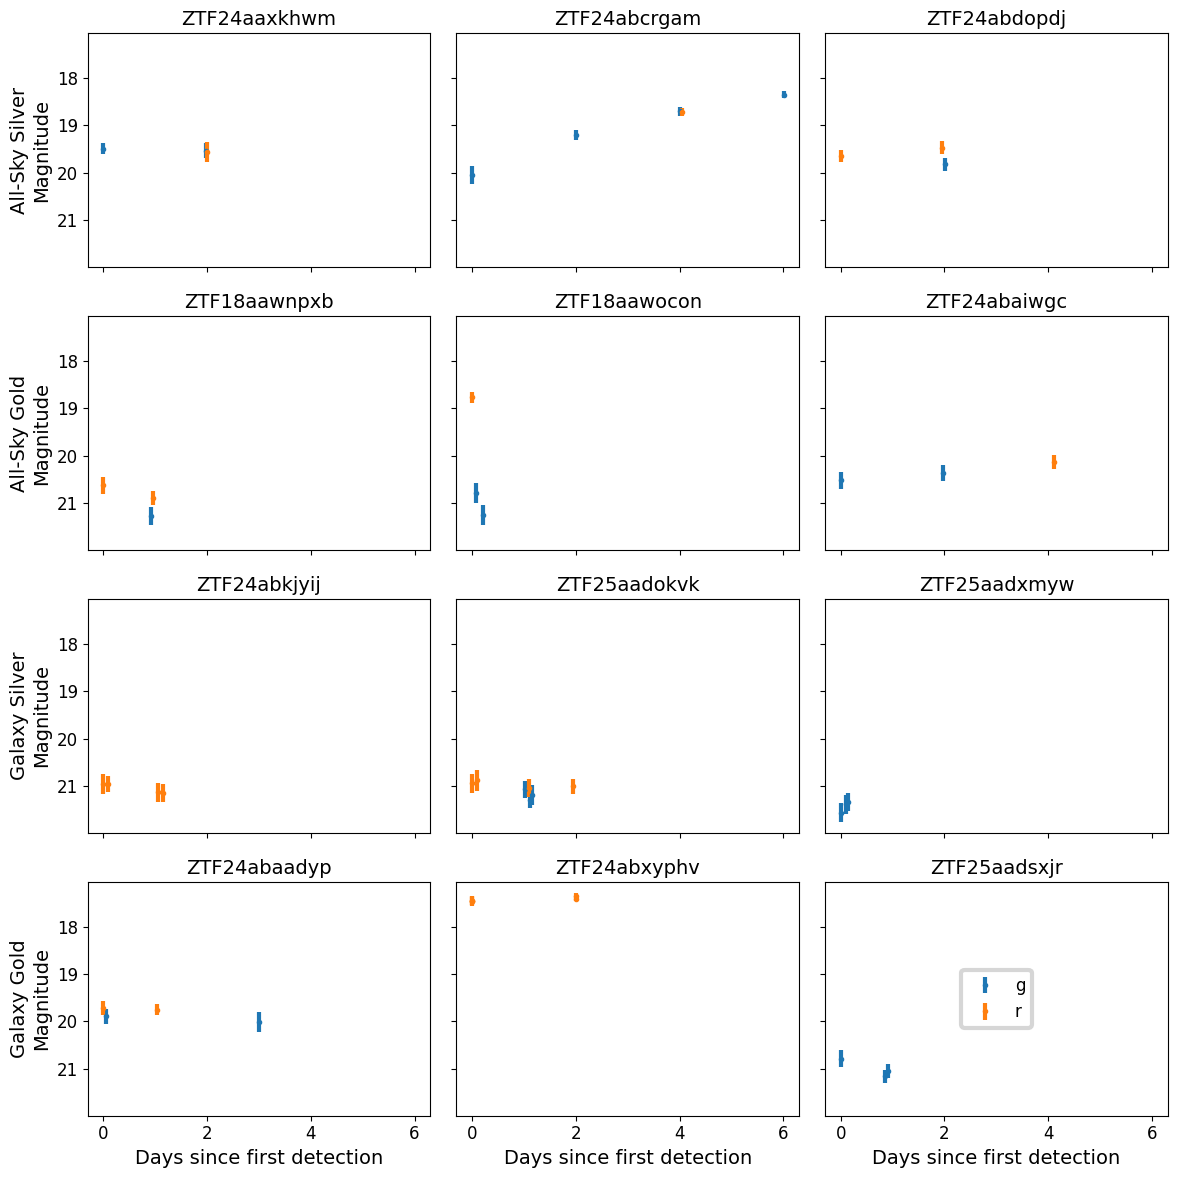

In [94]:
import matplotlib.pyplot as plt

n_cols = 3
n_rows = len(filtering_stages_2)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), sharex=True, sharey=True)

used_ids = set()

# First pass: collect IDs from bottom to top
ids_per_stage = []
for desc, df, full_desc in reversed(filtering_stages_2):
    counts = df.groupby('objectId').size()
    ids_more_than_2 = counts[counts > 2].index.tolist()
    ids_more_than_2 = [k for k in ids_more_than_2 if k not in ['ZTF18acalfrx', "ZTF24aaxgcyi","ZTF24aaxoasg","ZTF24aayqbgq","ZTF24aayrsfb"]]
    
    # Exclude already used objectIds
    ids_more_than_2 = [k for k in ids_more_than_2 if k not in used_ids]
    
    # Mark first n_cols as used
    for idx in ids_more_than_2[:n_cols]:
        used_ids.add(idx)
    
    ids_per_stage.append(ids_more_than_2)

# Reverse to match original order
ids_per_stage = ids_per_stage[::-1]

# Second pass: plot
for i, (desc, df, full_desc) in enumerate(filtering_stages_2):
    ids_more_than_2 = ids_per_stage[i]
    
    for j in range(n_cols):
        ax = axes[i, j] if n_rows > 1 else axes[j]
        
        if j < len(ids_more_than_2):
            idx = ids_more_than_2[j]
            df_obj = df[df['objectId'] == idx]
            jd_min = df_obj['jd'].min()
            
            for flt in [1, 2]:
                df_flt = df_obj[df_obj['fid'] == flt]
                ax.errorbar(df_flt['jd'] - jd_min, df_flt['magpsf'], yerr=df_flt['sigmapsf'], 
                           fmt='o', label=f'Filter {flt}', markersize=3)
            ax.set_title(f"{idx}", fontsize=14)
            if j == 0:
                ax.set_ylabel(f"{desc}\nMagnitude", fontsize=14)
            if i == n_rows - 1:
                ax.set_xlabel("Days since first detection", fontsize=14)
            ax.tick_params(labelsize=12)
        else:
            ax.axis('off')

# Invert y-axis once for all shared axes
axes[0, 0].invert_yaxis()

# Add legend to last row, last column (without a plot)
ax_legend = axes[n_rows - 1, n_cols - 1]
handles, labels = axes[0, 0].get_legend_handles_labels()
ax_legend.legend(handles, ['g', 'r'], fontsize=12, loc='center')

plt.tight_layout()
plt.show()

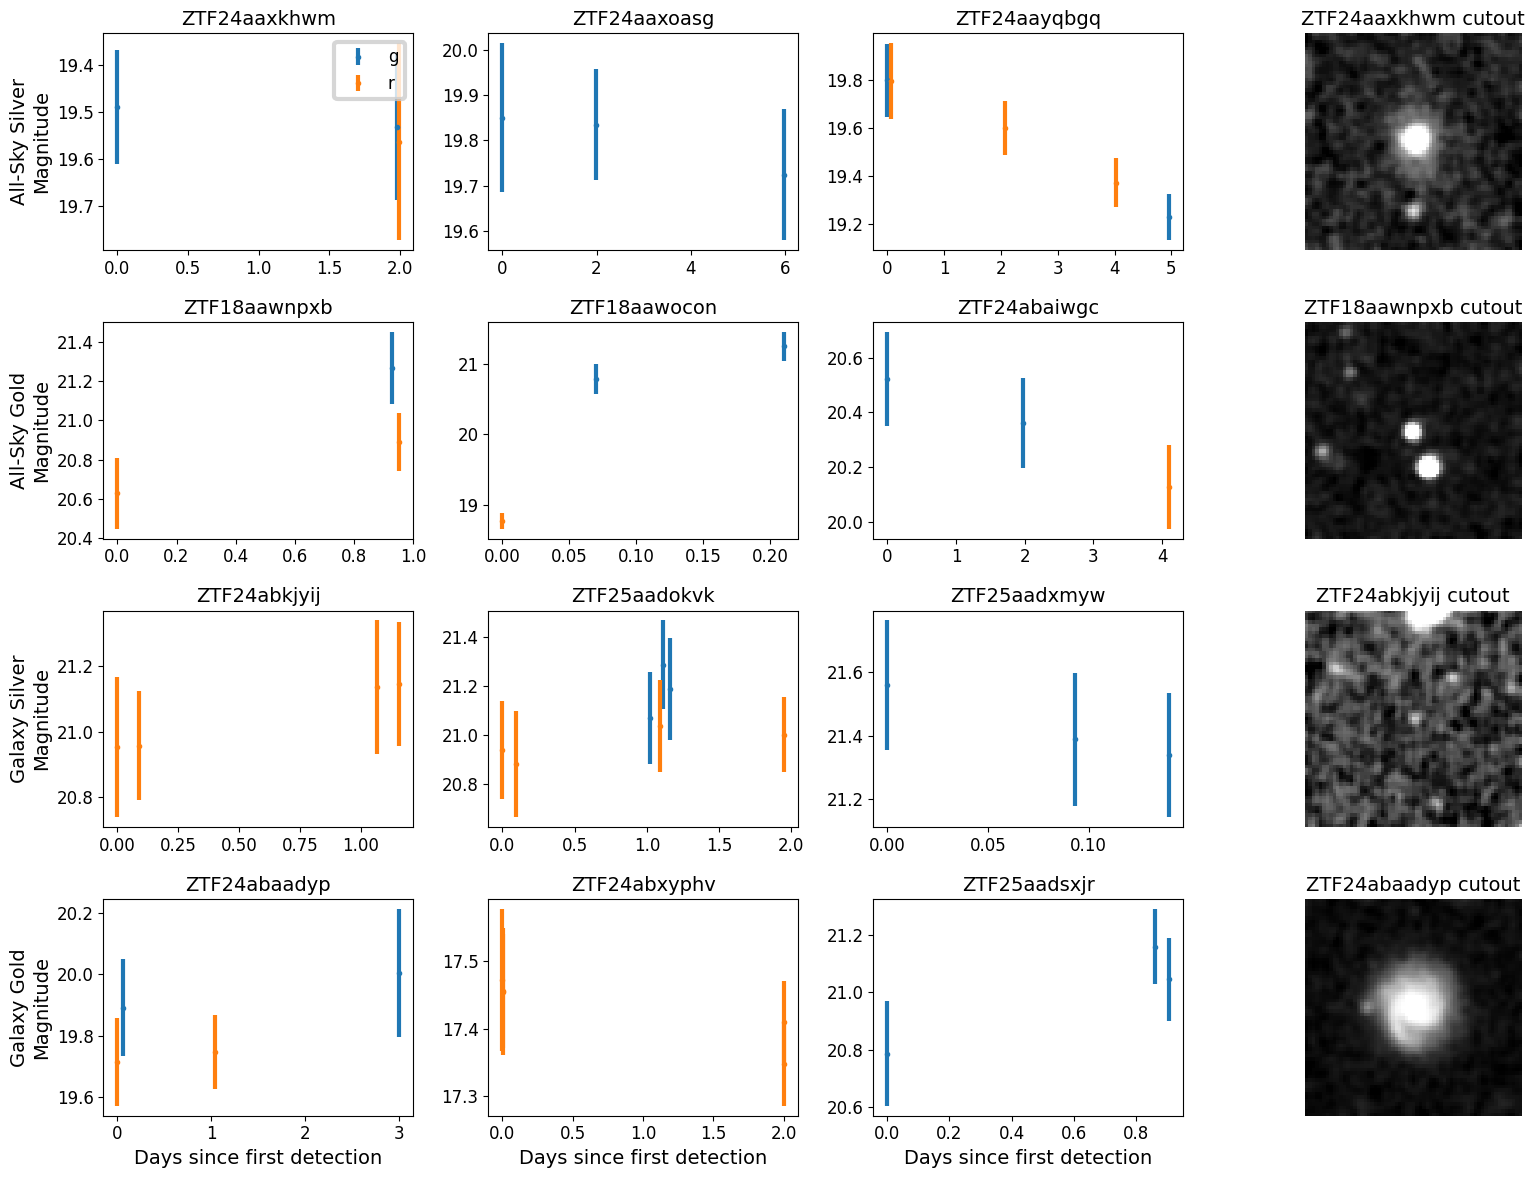

In [98]:
import matplotlib.pyplot as plt
import requests
import io
import numpy as np
from scipy.ndimage import gaussian_filter

n_cols = 4  # 3 light curves + 1 cutout
n_rows = len(filtering_stages_2)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

used_ids = set()

# First pass: collect IDs from bottom to top
ids_per_stage = []
for desc, df, full_desc in reversed(filtering_stages_2):
    counts = df.groupby('objectId').size()
    ids_more_than_2 = counts[counts > 2].index.tolist()
    ids_more_than_2 = [k for k in ids_more_than_2 if k not in ['ZTF18acalfrx', "ZTF24aaxgcyi"]]
    
    # Exclude already used objectIds
    ids_more_than_2 = [k for k in ids_more_than_2 if k not in used_ids]
    
    # Mark first 3 as used (for light curves)
    for idx in ids_more_than_2[:3]:
        used_ids.add(idx)
    
    ids_per_stage.append(ids_more_than_2)

# Reverse to match original order
ids_per_stage = ids_per_stage[::-1]

# Second pass: plot
for i, (desc, df, full_desc) in enumerate(filtering_stages_2):
    ids_more_than_2 = ids_per_stage[i]
    
    # Plot light curves in first 3 columns
    for j in range(3):
        ax = axes[i, j] if n_rows > 1 else axes[j]
        
        if j < len(ids_more_than_2):
            idx = ids_more_than_2[j]
            df_obj = df[df['objectId'] == idx]
            jd_min = df_obj['jd'].min()
            
            for flt in [1, 2]:
                df_flt = df_obj[df_obj['fid'] == flt]
                ax.errorbar(df_flt['jd'] - jd_min, df_flt['magpsf'], yerr=df_flt['sigmapsf'], 
                           fmt='o', label=f'Filter {flt}', markersize=3)
            ax.set_title(f"{idx}", fontsize=14)
            if j == 0:
                ax.set_ylabel(f"{desc}\nMagnitude", fontsize=14)
            if i == n_rows - 1:
                ax.set_xlabel("Days since first detection", fontsize=14)
            ax.tick_params(labelsize=12)
        else:
            ax.axis('off')
    
    # Plot cutout in 4th column (use first object of this row)
    ax_cutout = axes[i, 3] if n_rows > 1 else axes[3]
    
    if len(ids_more_than_2) > 0:
        idx = ids_more_than_2[0]
        
        # Fetch cutout
        r = requests.post(
            "https://api.fink-portal.org/api/v1/objects",
            json={
                "objectId": idx,
                "withcutouts": True
            }
        )
        pdf = pd.read_json(io.BytesIO(r.content))
        
        # Get science cutout
        data = pdf["b:cutoutScience_stampData"].to_numpy()[0]
        data = np.nan_to_num(data)
        data = data[::-1]
        data = gaussian_filter(data, sigma=1)
        
        # Normalize
        vmin, vmax = np.percentile(data, [1, 99])
        
        ax_cutout.imshow(data, cmap='Greys_r', vmin=vmin, vmax=vmax)
        ax_cutout.set_title(f"{idx} cutout", fontsize=14)
        ax_cutout.axis('off')
    else:
        ax_cutout.axis('off')

# Invert y-axis once for light curve axes
axes[0, 0].invert_yaxis()

# Add legend to an empty spot or use figlegend
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend(['g', 'r'], fontsize=12, loc='upper right')

plt.tight_layout()
plt.savefig("paper_plots/Fink_ZTF_filtered_candidates_lightcurves_cutouts.png")